In [1]:
# ─── Cell 1: Install extra packages ─────────────────────────────────
# Kaggle already has: torch, torchvision, numpy, matplotlib
# We only need to add these three:
 
!pip install -q scikit-learn   # for accuracy_score, confusion_matrix
!pip install -q seaborn        # for prettier confusion matrix heatmap
# (gradio is optional — only needed for Section 6 bonus demo)
 
print('All extra packages installed!')
 
# Expected output:
#   All extra packages installed!


All extra packages installed!


In [2]:
# ─── Cell 2: Import all required libraries ───────────────────────────
 
import torch                                    # core deep learning library

In [3]:
import torch.nn as nn                           # neural network layers (Linear, etc.)
import torch.optim as optim                     # optimisers: Adam, SGD, etc.
from torch.utils.data import DataLoader, random_split, Subset
 
import torchvision                              # CV datasets and pretrained models
import torchvision.transforms as transforms     # image preprocessing pipeline
from torchvision import models, datasets        # ResNet18, CIFAR10, etc.
 
from PIL import Image                           # Pillow: load single image files
import numpy as np                              # numerical array operations
import matplotlib.pyplot as plt                 # plotting images and curves
import seaborn as sns                           # heatmap for confusion matrix
 
from sklearn.metrics import (                   # evaluation metrics
    accuracy_score,
    classification_report,
    confusion_matrix
)
 
import os, warnings
warnings.filterwarnings('ignore')               # suppress non-critical warnings
 
# ── Detect device ─────────────────────────────────────────────────────
# torch.cuda.is_available() returns True if a GPU is found
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device in use : {device}')
print(f'PyTorch version: {torch.__version__}')
 
# Expected output (with GPU):
#   Device in use : cuda
#   PyTorch version: 2.x.x

Device in use : cuda
PyTorch version: 2.10.0+cu128


In [4]:
# ─── Cell 3: Define transforms for training and validation ───────────
 
# TRAINING TRANSFORMS (with augmentation)
# Augmentation = randomly modifying images to create variety.
# The model sees a slightly different version of each image every epoch.
# This is the #1 way to prevent overfitting on small datasets.
 
train_transform = transforms.Compose([
    # --- Augmentation steps (only applied during training) ---
    transforms.RandomHorizontalFlip(p=0.5),     # mirror 50% of images
    transforms.RandomRotation(degrees=10),       # rotate ±10 degrees
    transforms.ColorJitter(
        brightness=0.2,                          # ±20% brightness
        contrast=0.2,                            # ±20% contrast
        saturation=0.1                           # ±10% colour intensity
    ),
    transforms.RandomCrop(32, padding=4),        # pad 4px then random crop
 
    # --- Required preprocessing steps ---
    transforms.Resize((224, 224)),               # ResNet18 needs 224x224
    transforms.ToTensor(),                       # PIL Image → PyTorch tensor
    transforms.Normalize(                        # normalise using ImageNet stats
        mean=[0.485, 0.456, 0.406],              # mean for R, G, B channels
        std=[0.229, 0.224, 0.225]                # std  for R, G, B channels
    )
])
 
# VALIDATION / TEST TRANSFORMS (no augmentation)
# Always the same steps so we measure performance consistently.
 
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),               # same size as training
    transforms.ToTensor(),                       # PIL Image → tensor
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],              # SAME normalisation values
        std=[0.229, 0.224, 0.225]
    )
])
 
print('Transforms defined successfully!')
print('  Training : resize + augmentation + normalize')
print('  Validation: resize + normalize only')

Transforms defined successfully!
  Training : resize + augmentation + normalize
  Validation: resize + normalize only


In [5]:
# ─── Cell 4: Download CIFAR-10 and create mini (5,000-image) subset ──
 
print('Downloading CIFAR-10 dataset (first run only — ~170 MB)...')
 
# Download the full datasets
# train=True  → 50,000 training images
# train=False → 10,000 test images
# download=True → fetch from internet if not cached
full_train_raw = datasets.CIFAR10(
    root='./data', train=True,  download=True, transform=train_transform
)
full_test_raw  = datasets.CIFAR10(
    root='./data', train=False, download=True, transform=val_transform
)
 
print(f'Full training set: {len(full_train_raw):,} images')
print(f'Full test set    : {len(full_test_raw):,} images')
 
# ── Helper: pick N images per class to make a balanced mini subset ────
import random
random.seed(42)  # fixed seed = same mini set every run
 
def make_balanced_subset(dataset, n_per_class=500, num_classes=10):
    """Return a Subset with exactly n_per_class images per class."""
    # dataset.targets is a list with the class label for every image
    targets = dataset.targets if hasattr(dataset, 'targets') else [y for _, y in dataset]
 
    indices_per_class = {c: [] for c in range(num_classes)}
    for idx, label in enumerate(targets):
        indices_per_class[label].append(idx)
 
    selected = []
    for c in range(num_classes):
        pool = indices_per_class[c]
        random.shuffle(pool)
        selected.extend(pool[:n_per_class])  # take first n_per_class
 
    random.shuffle(selected)  # mix all classes together
    return Subset(dataset, selected)
 
# Create mini subsets
# Training: 500 images × 10 classes = 5,000 total
# Test:     100 images × 10 classes = 1,000 total (fast evaluation)
mini_train_full = make_balanced_subset(full_train_raw, n_per_class=500)
mini_test       = make_balanced_subset(full_test_raw,  n_per_class=100)
 
print(f'Mini training set: {len(mini_train_full)} images')
print(f'Mini test set    : {len(mini_test)} images')
 
# Class names for display
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
print(f'Classes: {class_names}')

100%|██████████| 170M/170M [00:03<00:00, 43.6MB/s] 


Full training set: 50,000 images
Full test set    : 10,000 images
Mini training set: 5000 images
Mini test set    : 1000 images
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [6]:
# ─── Cell 5: Split mini training set into train (80%) / val (20%) ────
 
# 80% of 5,000 = 4,000 training  |  20% of 5,000 = 1,000 validation
train_size = int(0.8 * len(mini_train_full))   # = 4000
val_size   = len(mini_train_full) - train_size  # = 1000
 
# random_split divides the dataset randomly
# generator= with a fixed seed ensures the same split every run
train_dataset, val_dataset = random_split(
    mini_train_full,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)
 
# mini_test was already created in Cell 4 — we use it as-is
test_dataset = mini_test
 
print('Dataset split summary:')
print(f'  Training   : {len(train_dataset):>5} images  (80%)')
print(f'  Validation : {len(val_dataset):>5} images  (20%)')
print(f'  Test       : {len(test_dataset):>5} images  (held-out)')
 
# Expected output:
#   Dataset split summary:
#     Training   :  4000 images  (80%)
#     Validation :  1000 images  (20%)
#     Test       :  1000 images  (held-out)

Dataset split summary:
  Training   :  4000 images  (80%)
  Validation :  1000 images  (20%)
  Test       :  1000 images  (held-out)


In [7]:
# ─── Cell 6: Create DataLoaders ─────────────────────────────────────
 
BATCH_SIZE = 32  # number of images processed in one forward/backward pass
                 # reduce to 16 if you see 'CUDA out of memory'
 
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,      # randomise order each epoch (critical for training!)
    num_workers=2,     # 2 background threads for faster data loading
    pin_memory=True    # faster GPU transfers (ignored on CPU)
)
 
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,     # no need to shuffle — we just measure performance
    num_workers=2,
    pin_memory=True
)
 
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)
 
print(f'DataLoaders created  (batch size = {BATCH_SIZE})')
print(f'  Training batches  : {len(train_loader)}')
print(f'  Validation batches: {len(val_loader)}')
print(f'  Test batches      : {len(test_loader)}')
 
# Expected output:
#   DataLoaders created  (batch size = 32)
#     Training batches  : 125
#     Validation batches: 32
#     Test batches      : 32

DataLoaders created  (batch size = 32)
  Training batches  : 125
  Validation batches: 32
  Test batches      : 32


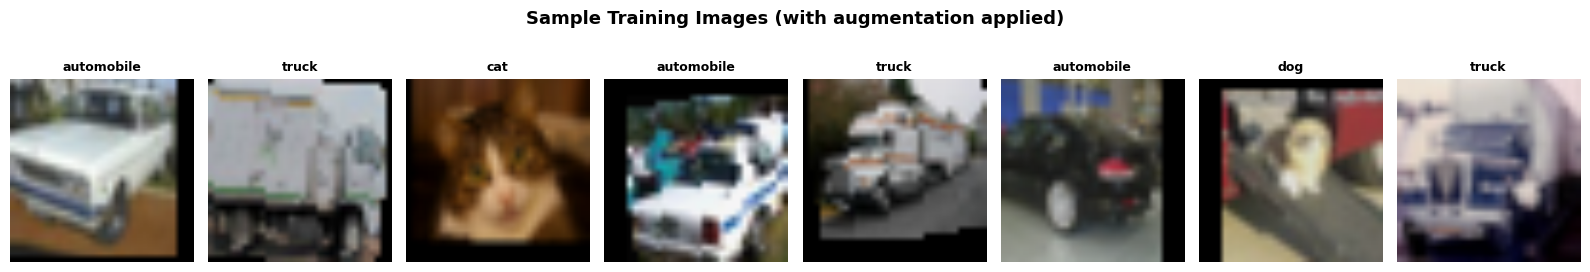

Notice: some images look slightly rotated or flipped — that is augmentation!


In [8]:
# ─── Cell 7: Display 8 sample training images ────────────────────────
 
def denormalize(tensor):
    """Reverse the Normalize transform so we can display the image normally.
    Normalisation formula:  normalised = (original - mean) / std
    Reverse formula:        original   = (normalised * std) + mean
    """
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (tensor * std) + mean
 
# Grab one batch from the training DataLoader
images, labels = next(iter(train_loader))
 
fig, axes = plt.subplots(1, 8, figsize=(16, 3))
 
for i in range(8):
    # denormalize → permute (C,H,W) to (H,W,C) for matplotlib → clip to [0,1]
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)                 # ensures no values outside [0,1]
    axes[i].imshow(img)
    axes[i].set_title(class_names[labels[i].item()], fontsize=9, fontweight='bold')
    axes[i].axis('off')                      # hide axis ticks and labels
 
plt.suptitle('Sample Training Images (with augmentation applied)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
 
print('Notice: some images look slightly rotated or flipped — that is augmentation!')

In [9]:
# ─── Cell 8: Load pretrained ResNet18 and adapt for 10-class output ──
 
# Load ResNet18 with ImageNet pretrained weights
# weights='DEFAULT' → best available weights (replaces deprecated pretrained=True)
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
 
# Inspect the original final layer before we change it
print('Original final layer (fc):', model.fc)
# → Linear(in_features=512, out_features=1000, bias=True)
# ResNet18 originally predicts 1000 ImageNet classes — we need 10.
 
# ── Step 1: Freeze ALL pretrained layers ─────────────────────────────
# Setting requires_grad=False means PyTorch will NOT update these weights
# during backpropagation. We preserve the ImageNet knowledge.
for param in model.parameters():
    param.requires_grad = False
 
print('All pretrained layers frozen (weights locked).')
 
# ── Step 2: Replace the final fully-connected layer ──────────────────
# model.fc.in_features = 512 (the number of features entering the last layer)
# We keep 512 inputs but change the output to 10 (our number of classes)
# The new nn.Linear layer has requires_grad=True by default
NUM_CLASSES = 10
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
 
print(f'New final layer (fc)    : {model.fc}')
# → Linear(in_features=512, out_features=10, bias=True)
 
# ── Step 3: Move model to the correct device ──────────────────────────
model = model.to(device)
 
# ── Count parameters ─────────────────────────────────────────────────
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
 
print(f'Trainable parameters : {trainable:>10,}  ({100*trainable/total:.2f}%)')
print(f'Frozen parameters    : {total-trainable:>10,}  ({100*(total-trainable)/total:.2f}%)')
 
# Expected output:
#   Trainable parameters :      5,130  (0.05%)
#   Frozen parameters    : 11,176,512  (99.95%)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 142MB/s] 


Original final layer (fc): Linear(in_features=512, out_features=1000, bias=True)
All pretrained layers frozen (weights locked).
New final layer (fc)    : Linear(in_features=512, out_features=10, bias=True)
Trainable parameters :      5,130  (0.05%)
Frozen parameters    : 11,176,512  (99.95%)


In [10]:
# ─── Cell 9: Configure the training components ───────────────────────
 
# ── Loss Function ────────────────────────────────────────────────────
# CrossEntropyLoss is the standard loss for multi-class classification.
# It measures how wrong the model's predictions are.
# Goal of training: minimise this number.
criterion = nn.CrossEntropyLoss()
 
# ── Optimiser ────────────────────────────────────────────────────────
# Adam (Adaptive Moment Estimation) automatically adjusts the step size
# for each parameter. It is the most popular optimiser for beginners.
#
# IMPORTANT: pass model.fc.parameters() NOT model.parameters()
# We only want to update the new final layer — not the frozen layers.
optimizer = optim.Adam(
    model.fc.parameters(),   # only optimise the new classifier head
    lr=0.001                 # learning rate: size of each weight update step
)
 
# ── Learning Rate Scheduler ───────────────────────────────────────────
# Reduces the learning rate when validation loss stops improving.
# Think of it as taking smaller steps as you get close to the answer.
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',    # reduce LR when the monitored value stops going DOWN
    patience=2,    # wait 2 epochs before reducing
    factor=0.5     # new_lr = old_lr × 0.5
)
 
print('Training components ready:')
print('  Loss function : CrossEntropyLoss')
print('  Optimiser     : Adam  (lr=0.001)')
print('  LR Scheduler  : ReduceLROnPlateau  (patience=2, factor=0.5)')

Training components ready:
  Loss function : CrossEntropyLoss
  Optimiser     : Adam  (lr=0.001)
  LR Scheduler  : ReduceLROnPlateau  (patience=2, factor=0.5)


In [11]:
# ─── Cell 10: Define training and validation helper functions ─────────
 
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Train the model for exactly one epoch.
    Returns: (average_loss, accuracy_percent)
    """
    model.train()       # CRITICAL: sets model to training mode
                        # enables Dropout and BatchNorm training behaviour
    total_loss = 0.0
    correct    = 0
    total      = 0
 
    for batch_idx, (images, labels) in enumerate(loader):
 
        # Move this batch to GPU (or CPU if no GPU)
        images = images.to(device)
        labels = labels.to(device)
 
        # Step 1 — Clear accumulated gradients from the previous batch
        # (If you forget this, gradients pile up and the model explodes!)
        optimizer.zero_grad()
 
        # Step 2 — Forward pass: feed images through the model
        outputs = model(images)          # shape: (batch_size, 10)
 
        # Step 3 — Calculate loss: how wrong are our predictions?
        loss = criterion(outputs, labels)
 
        # Step 4 — Backward pass: compute gradients
        loss.backward()
 
        # Step 5 — Optimiser step: update the trainable weights
        optimizer.step()
 
        # Accumulate statistics for reporting
        total_loss += loss.item()
        _, predicted = torch.max(outputs, dim=1)   # class with highest score
        total      += labels.size(0)               # number of images in batch
        correct    += (predicted == labels).sum().item()
 
        # Print progress every 50 batches so you know it's running
        if batch_idx % 50 == 0:
            print(f'    Batch {batch_idx:3d}/{len(loader)} | Loss: {loss.item():.4f}')
 
    avg_loss = total_loss / len(loader)
    accuracy = 100.0 * correct / total
    return avg_loss, accuracy
 
 
def evaluate(model, loader, criterion, device):
    """Evaluate model on validation or test data.
    No weight updates — only measure performance.
    Returns: (average_loss, accuracy_percent)
    """
    model.eval()        # sets model to evaluation mode
                        # disables Dropout; BatchNorm uses running statistics
    total_loss = 0.0
    correct    = 0
    total      = 0
 
    # torch.no_grad() disables gradient computation entirely
    # This saves memory and speeds up evaluation (~2x faster)
    with torch.no_grad():
        for images, labels in loader:
            images  = images.to(device)
            labels  = labels.to(device)
            outputs = model(images)
            loss    = crterion(outputs, labels)
 
            total_loss += loss.item()
            _, predicted = torch.max(outputs, dim=1)
            total      += labels.size(0)
            correct    += (predicted == labels).sum().item()
 
    avg_loss = total_loss / len(loader)
    accuracy = 100.0 * correct / total
    return avg_loss, accuracy
 
print('Training and evaluation functions defined!')


Training and evaluation functions defined!


In [21]:
# ─── Cell 11: Main training loop ─────────────────────────────────────
 
NUM_EPOCHS   = 10          # 10 full passes over the training data
best_val_acc = 0.0         # track the best validation accuracy seen so far
 
# Store metrics each epoch so we can plot curves later
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc' : [], 'val_acc' : []
}
 
print('=' * 60)
print('  STARTING TRAINING')
print(f'  Epochs: {NUM_EPOCHS}  |  Training batches per epoch: {len(train_loader)}')
print('=' * 60)
 
for epoch in range(1, NUM_EPOCHS + 1):
 
    print(f'\nEpoch {epoch}/{NUM_EPOCHS}')
    print('-' * 40)
 
    # ── Training phase ────────────────────────────────────────────────
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )
 
    # ── Validation phase ──────────────────────────────────────────────
    val_loss, val_acc = evaluate(
        model, val_loader, criterion, device
    )
 
    # ── Update learning rate scheduler ────────────────────────────────
    # Pass the validation loss so the scheduler knows if we are improving
    scheduler.step(val_loss)
 
    # ── Record metrics ─────────────────────────────────────────────────
    history['train_loss'].append(train_loss)
    history['val_loss'  ].append(val_loss)
    history['train_acc' ].append(train_acc)
    history['val_acc'   ].append(val_acc)
 
    # ── Print epoch summary ───────────────────────────────────────────
    print(f'  Train →  Loss: {train_loss:.4f}  |  Accuracy: {train_acc:.2f}%')
    print(f'  Val   →  Loss: {val_loss:.4f}  |  Accuracy: {val_acc:.2f}%')
 
    # ── Save the best model ───────────────────────────────────────────
    # We only save when validation accuracy improves, so 'best_model.pth'
    # always contains the checkpoint with the highest validation accuracy.
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
        print(f'  NEW BEST MODEL saved!  Val Accuracy: {val_acc:.2f}%')
 
print('\n' + '=' * 60)
print('  TRAINING COMPLETE!')
print(f'  Best validation accuracy: {best_val_acc:.2f}%')
print('=' * 60)
 
# Expected training time on Kaggle GPU: approximately 2-4 minutes total
# Expected best val accuracy after 10 epochs: 70-80%


  STARTING TRAINING
  Epochs: 10  |  Training batches per epoch: 125

Epoch 1/10
----------------------------------------
    Batch   0/125 | Loss: 0.9735
    Batch  50/125 | Loss: 0.9214
    Batch 100/125 | Loss: 0.9423
  Train →  Loss: 1.0415  |  Accuracy: 65.00%
  Val   →  Loss: 1.0125  |  Accuracy: 65.30%
  NEW BEST MODEL saved!  Val Accuracy: 65.30%

Epoch 2/10
----------------------------------------
    Batch   0/125 | Loss: 1.2520
    Batch  50/125 | Loss: 1.0073
    Batch 100/125 | Loss: 1.0321
  Train →  Loss: 0.9736  |  Accuracy: 66.45%
  Val   →  Loss: 0.9486  |  Accuracy: 66.90%
  NEW BEST MODEL saved!  Val Accuracy: 66.90%

Epoch 3/10
----------------------------------------
    Batch   0/125 | Loss: 0.8713
    Batch  50/125 | Loss: 1.0032
    Batch 100/125 | Loss: 1.3124
  Train →  Loss: 0.9458  |  Accuracy: 68.90%
  Val   →  Loss: 0.9445  |  Accuracy: 67.20%
  NEW BEST MODEL saved!  Val Accuracy: 67.20%

Epoch 4/10
----------------------------------------
    Batch   0/

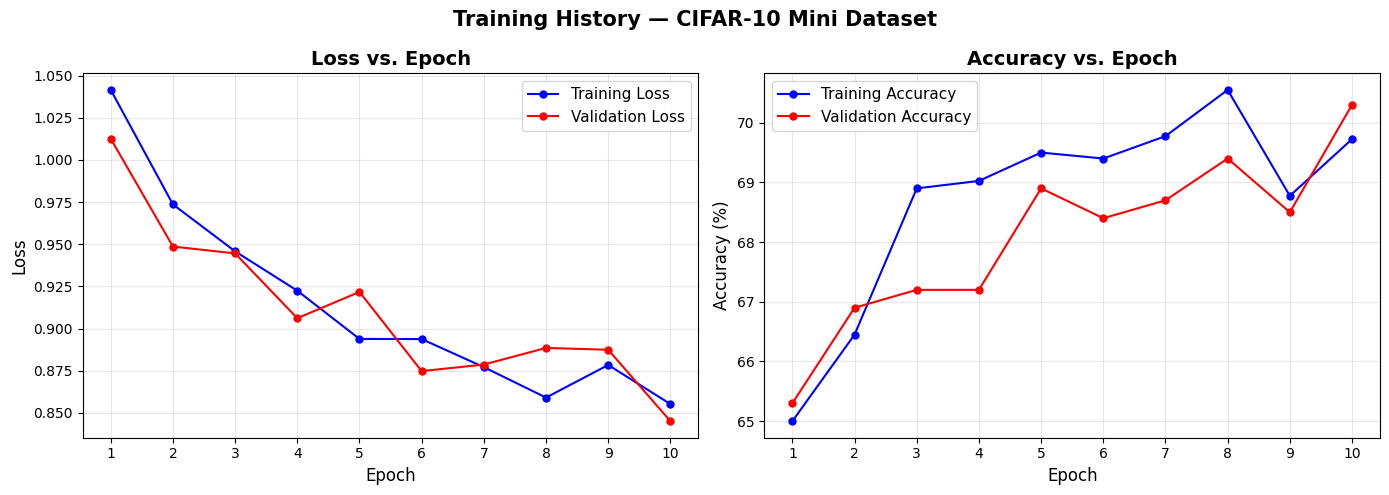

Good! Train-val gap is -0.6% -- model generalises well.


In [22]:
# ─── Cell 12: Plot loss and accuracy curves ───────────────────────────
 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
 
epochs_range = range(1, NUM_EPOCHS + 1)
 
# ── Loss subplot ──────────────────────────────────────────────────────
ax1.plot(epochs_range, history['train_loss'], 'b-o', label='Training Loss',   markersize=5)
ax1.plot(epochs_range, history['val_loss'],   'r-o', label='Validation Loss', markersize=5)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss',  fontsize=12)
ax1.set_title('Loss vs. Epoch', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(list(epochs_range))
 
# ── Accuracy subplot ──────────────────────────────────────────────────
ax2.plot(epochs_range, history['train_acc'], 'b-o', label='Training Accuracy',   markersize=5)
ax2.plot(epochs_range, history['val_acc'],   'r-o', label='Validation Accuracy', markersize=5)
ax2.set_xlabel('Epoch',       fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Accuracy vs. Epoch', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(list(epochs_range))
 
plt.suptitle('Training History — CIFAR-10 Mini Dataset', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=120, bbox_inches='tight')
plt.show()
 
# ── Overfitting check ─────────────────────────────────────────────────
final_gap = history['train_acc'][-1] - history['val_acc'][-1]
 
if final_gap > 15:
    print(f'WARNING: Large train-val gap ({final_gap:.1f}%) -- possible overfitting!')
    print('Fix: add more augmentation, or reduce learning rate.')
elif final_gap < -5:
    print(f'NOTE: Validation ({history["val_acc"][-1]:.1f}%) > Training ({history["train_acc"][-1]:.1f}%)')
    print('This can happen with strong augmentation -- usually fine.')
else:
    print(f'Good! Train-val gap is {final_gap:.1f}% -- model generalises well.')


In [24]:
# ─── Cell 13: Evaluate on the held-out test set ──────────────────────
 
# Load the best model weights saved during training
# map_location=device handles the case where you saved on GPU but load on CPU
model.load_state_dict(torch.load('best_model.pth', map_location=device))
model.eval()   # always set eval mode before inference!
 
all_preds  = []    # will hold predicted class indices
all_labels = []    # will hold true class indices
 
with torch.no_grad():   # no gradients needed for evaluation
    for images, labels in test_loader:
        images  = images.to(device)
        outputs = model(images)              # raw scores (logits)
        _, predicted = torch.max(outputs, dim=1)  # pick highest-score class
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())
 
# ── Overall accuracy ─────────────────────────────────────────────────
test_acc = accuracy_score(all_labels, all_preds)
print(f'Test Accuracy: {test_acc:.4f}  ({test_acc*100:.2f}%)')
 
# ── Per-class classification report ──────────────────────────────────
# Precision: of all predictions for class X, how many were correct?
# Recall:    of all real class X images, how many did we catch?
# F1-score:  harmonic mean of precision and recall (balanced metric)
print('\nClassification Report:')
print(classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    digits=3             # show 3 decimal places
))

Test Accuracy: 0.7630  (76.30%)

Classification Report:
              precision    recall  f1-score   support

    airplane      0.791     0.720     0.754       100
  automobile      0.677     0.900     0.773       100
        bird      0.637     0.790     0.705       100
         cat      0.584     0.660     0.620       100
        deer      0.851     0.630     0.724       100
         dog      0.736     0.810     0.771       100
        frog      0.813     0.870     0.841       100
       horse      0.904     0.750     0.820       100
        ship      0.917     0.770     0.837       100
       truck      0.901     0.730     0.807       100

    accuracy                          0.763      1000
   macro avg      0.781     0.763     0.765      1000
weighted avg      0.781     0.763     0.765      1000



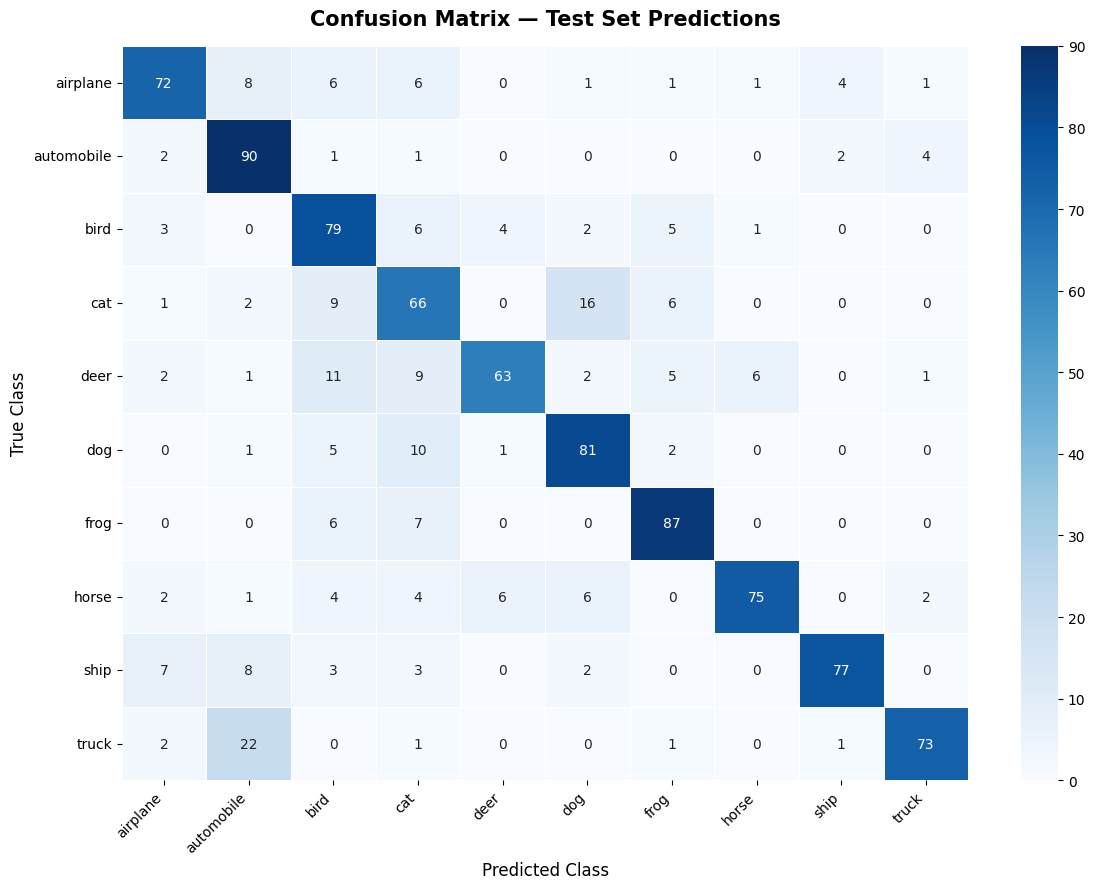

Most common mistake:
  True class  : truck
  Predicted as: automobile
  Times        : 22

Per-class accuracy:
  airplane     ##############       72.0%
  automobile   ##################   90.0%
  bird         ###############      79.0%
  cat          #############        66.0%
  deer         ############         63.0%
  dog          ################     81.0%
  frog         #################    87.0%
  horse        ###############      75.0%
  ship         ###############      77.0%
  truck        ##############       73.0%


In [25]:
# ─── Cell 14: Confusion matrix visualisation ─────────────────────────
 
# A confusion matrix shows where the model makes mistakes.
# Rows = true class  |  Columns = predicted class
# Diagonal cells    = correct predictions (we want these to be large)
# Off-diagonal cells = mistakes (what the model confused with what)
 
cm = confusion_matrix(all_labels, all_preds)
 
plt.figure(figsize=(12, 9))
sns.heatmap(
    cm,
    annot=True,           # show the count number in each cell
    fmt='d',              # format as integer (no decimals)
    cmap='Blues',         # blue colour map
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    linecolor='white'
)
plt.title('Confusion Matrix — Test Set Predictions', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('True Class',      fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()
 
# ── Find the most confused pair ───────────────────────────────────────
cm_copy = cm.copy()
np.fill_diagonal(cm_copy, 0)   # zero out correct predictions
worst   = np.unravel_index(cm_copy.argmax(), cm_copy.shape)
print(f'Most common mistake:')
print(f'  True class  : {class_names[worst[0]]}')
print(f'  Predicted as: {class_names[worst[1]]}')
print(f'  Times        : {cm_copy[worst]}')
 
# ── Per-class accuracy ────────────────────────────────────────────────
per_class = cm.diagonal() / cm.sum(axis=1)
print('\nPer-class accuracy:')
for i, name in enumerate(class_names):
    bar = '#' * int(per_class[i] * 20)
    print(f'  {name:12s} {bar:<20} {per_class[i]:.1%}')

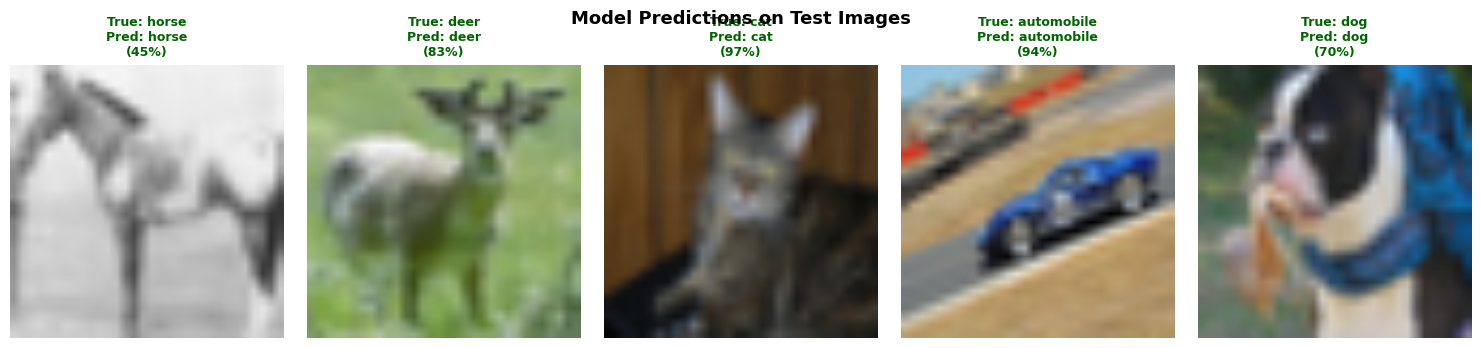

Green titles = correct  |  Red titles = incorrect


In [26]:
# ─── Cell 15: Show predictions on 5 test images side by side ─────────
 
# Grab one batch from the test loader
test_images, test_labels = next(iter(test_loader))
 
fig, axes = plt.subplots(1, 5, figsize=(15, 3.5))
 
model.eval()
 
for i in range(5):
 
    # Denormalize for display (reverse the Normalize transform)
    img_display = denormalize(test_images[i]).permute(1, 2, 0).numpy()
    img_display = np.clip(img_display, 0, 1)
 
    # Run prediction on this single image
    # .unsqueeze(0) adds the batch dimension: (C,H,W) → (1,C,H,W)
    single_input = test_images[i].unsqueeze(0).to(device)
 
    with torch.no_grad():
        output = model(single_input)              # shape: (1, 10)
        prob   = torch.nn.functional.softmax(output[0], dim=0)
        pred   = torch.argmax(prob).item()
        conf   = prob[pred].item()
 
    # Title: green if correct, red if wrong
    true_lbl = class_names[test_labels[i].item()]
    pred_lbl = class_names[pred]
    colour   = 'darkgreen' if pred == test_labels[i].item() else 'darkred'
 
    axes[i].imshow(img_display)
    axes[i].set_title(
        f'True: {true_lbl}\nPred: {pred_lbl}\n({conf:.0%})',
        fontsize=9, fontweight='bold', color=colour
    )
    axes[i].axis('off')
 
plt.suptitle('Model Predictions on Test Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('Green titles = correct  |  Red titles = incorrect')

In [27]:
# ─── Cell 16: predict_image() — works on any JPG/PNG file ────────────
 
def predict_image(image_path, model, class_names, device):
    """
    Load an image file, preprocess it, and return the predicted class.
 
    Args:
        image_path  : string path to any .jpg or .png file
        model       : trained PyTorch model (must be in eval() mode)
        class_names : list of class name strings
        device      : 'cuda' or 'cpu'
 
    Returns:
        predicted_class : string name of predicted class
        confidence      : float in [0, 1]  (e.g. 0.87 means 87% confident)
    """
    # ── Step 1: Load image ────────────────────────────────────────────
    # .convert('RGB') ensures colour images regardless of source format
    image = Image.open(image_path).convert('RGB')
 
    # ── Step 2: Apply EXACTLY the same preprocessing as validation ─────
    # This is critical — any mismatch here causes poor predictions
    preprocess = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std =[0.229, 0.224, 0.225]
        )
    ])
 
    # ── Step 3: Prepare tensor ────────────────────────────────────────
    tensor = preprocess(image)        # shape: (3, 224, 224)
    tensor = tensor.unsqueeze(0)      # add batch dim: (1, 3, 224, 224)
    tensor = tensor.to(device)
 
    # ── Step 4: Run inference ─────────────────────────────────────────
    model.eval()
    with torch.no_grad():
        outputs = model(tensor)       # raw scores, shape (1, 10)
 
    # ── Step 5: Convert to probabilities and get top prediction ───────
    probs = torch.nn.functional.softmax(outputs[0], dim=0)
    confidence, pred_idx = torch.max(probs, dim=0)
    predicted_class = class_names[pred_idx.item()]
 
    # ── Step 6: Display image + top-5 bar chart ───────────────────────
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
 
    ax1.imshow(image)
    ax1.set_title(
        f'Predicted: {predicted_class.upper()}\nConfidence: {confidence.item():.1%}',
        fontsize=13, fontweight='bold', color='navy'
    )
    ax1.axis('off')
 
    # Top-5 probability bar chart
    top5_probs, top5_idx = torch.topk(probs, 5)
    top5_names  = [class_names[i.item()] for i in top5_idx]
    top5_values = [p.item() * 100 for p in top5_probs]
 
    colours = ['#1565C0' if i == 0 else '#90CAF9' for i in range(5)]
    ax2.barh(top5_names[::-1], top5_values[::-1], color=colours[::-1])
    ax2.set_xlabel('Confidence (%)', fontsize=11)
    ax2.set_title('Top 5 Predictions', fontsize=12, fontweight='bold')
    ax2.set_xlim(0, 100)
 
    for j, (val, name) in enumerate(zip(top5_values[::-1], top5_names[::-1])):
        ax2.text(val + 1, j, f'{val:.1f}%', va='center', fontsize=10)
 
    plt.tight_layout()
    plt.show()
 
    return predicted_class, confidence.item()
 
 
print('predict_image() function defined and ready!')
print("Usage:  predict_image('path/to/my_photo.jpg', model, class_names, device)")

predict_image() function defined and ready!
Usage:  predict_image('path/to/my_photo.jpg', model, class_names, device)


Saved sample image.  True class: horse


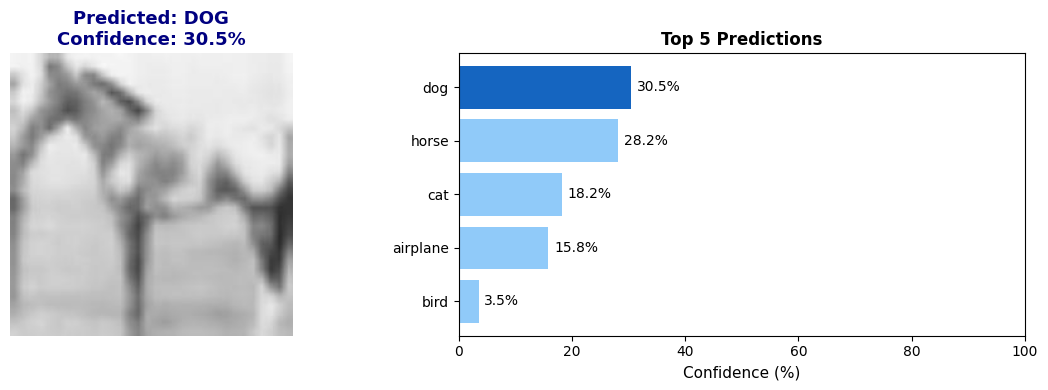

Predicted: dog  |  Confidence: 30.5%
WRONG — true class was horse


In [28]:
# ─── Cell 17: Test predict_image() using an image from the test set ──
 
# We save one test image to disk first so we can test the function
sample_img_tensor, sample_label = test_dataset[0]
 
# Denormalize and convert to PIL Image for saving
sample_pil = denormalize(sample_img_tensor).permute(1, 2, 0).numpy()
sample_pil = np.clip(sample_pil * 255, 0, 255).astype(np.uint8)
pil_img    = Image.fromarray(sample_pil)
pil_img.save('sample_test_image.jpg')
 
true_class = class_names[sample_label]
print(f'Saved sample image.  True class: {true_class}')
 
# Now run the inference function on it
pred, conf = predict_image('sample_test_image.jpg', model, class_names, device)
print(f'Predicted: {pred}  |  Confidence: {conf:.1%}')
 
if pred == true_class:
    print('CORRECT prediction!')
else:
    print(f'WRONG — true class was {true_class}')

In [30]:
# ─── Cell 18: Save a complete checkpoint and load it back ────────────
 
# ── Save a rich checkpoint (more information than just state_dict) ────
checkpoint = {
    'model_state_dict'    : model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'best_val_acc'        : best_val_acc,
    'class_names'         : class_names,
    'num_classes'         : NUM_CLASSES,
    'architecture'        : 'resnet18',
    'training_history'    : history
}
torch.save(checkpoint, 'cifar10_mini_checkpoint.pth')
print('Checkpoint saved to cifar10_mini_checkpoint.pth')
 
# ── Load the checkpoint and rebuild the model ─────────────────────────
def load_checkpoint(checkpoint_path, device):
    """Rebuild a ResNet18 classifier from a saved checkpoint."""
    ckpt = torch.load(checkpoint_path, map_location=device)
 
    # Recreate the same architecture
    loaded_model = models.resnet18(weights=None)  # no pretrained weights
    loaded_model.fc = nn.Linear(
        loaded_model.fc.in_features,
        ckpt['num_classes']
    )
 
    # Load our trained weights into the architecture
    loaded_model.load_state_dict(ckpt['model_state_dict'])
    loaded_model = loaded_model.to(device)
    loaded_model.eval()       # always set eval mode after loading!
 
    print(f"Loaded model from {checkpoint_path}")
    print(f"Best validation accuracy: {ckpt['best_val_acc']:.2f}%")
    return loaded_model, ckpt['class_names']
 
# Verify the load works
reloaded_model, reloaded_classes = load_checkpoint('cifar10_mini_checkpoint.pth', device)
print(f'Classes: {reloaded_classes}')

Checkpoint saved to cifar10_mini_checkpoint.pth
Loaded model from cifar10_mini_checkpoint.pth
Best validation accuracy: 70.30%
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
